In [1]:
import json
import pandas as pd
import numpy as np
from datetime import datetime,timedelta
import prettytable as pt
from matplotlib import pyplot as plt
import os
import warnings
warnings.filterwarnings("ignore")



###################################################################################################
                                                                                                  #
from rhoova.Client import *                                                                       #   
#Register and get api key from https://app.rhoova.com/ for ClientConfig("api key", "api secret")  #
config = ClientConfig("", "")                                                                     #
api = Api(config)                                                                                 # 
                                                                                                  #
###################################################################################################


directory = os.path.normpath(os.getcwd() + os.sep + os.pardir)
yielddatadirectory=directory+"/data/yielddata/bonddefiniton.csv"
marketdatadirectory=directory+"/data/marketdata/marketdata.csv"


bonddefiniton = pd.read_csv(yielddatadirectory,sep=';')
marketdata = pd.read_csv(marketdatadirectory,sep=';')

data=bonddefiniton.merge(marketdata[['valuationDate','isincode','value']], left_on='isincode', right_on='isincode')
data["valuationDate"]="2021-03-05"
data['issueDate'] = data['issueDate'].apply(lambda x: datetime.strptime(x, "%d.%m.%Y").strftime("%Y-%m-%d"))
data['maturityDate'] = data['maturityDate'].apply(lambda x: datetime.strptime(x, "%d.%m.%Y").strftime("%Y-%m-%d"))


In [2]:
# Rhoova expects date,convention,calendar input  as a string. Frequency values are Semiannual, Annual etc.
#6M,1Y cant be accepted.All inputs for fixedratebond are in https://app.rhoova.com/docs#post-/tasks/fixed-rate-bond

#Create empty dictionary to fill bond definition. Dictionary name is not case sensitive.
#It has to be define fixedRateBondDefinition

fixedRateBondDefinition={}
fixedRateBondDefinition["issueDate"]="2014-02-19"
fixedRateBondDefinition["maturityDate"]="2045-02-17"
fixedRateBondDefinition["frequency"]="Semiannual"
fixedRateBondDefinition["coupon"]=0.06625
fixedRateBondDefinition["calendar"]="Turkey"
fixedRateBondDefinition["currency"]="USD"
fixedRateBondDefinition["dateGeneration"]="Backward"
fixedRateBondDefinition["dayCounter"]="Thirty360E"
fixedRateBondDefinition["businessDayConvention"]="Unadjusted"
fixedRateBondDefinition["maturityDayConvention"]="Unadjusted"
fixedRateBondDefinition["redemption"]=100
fixedRateBondDefinition["endOfMonth"]=True
fixedRateBondDefinition

{'issueDate': '2014-02-19',
 'maturityDate': '2045-02-17',
 'frequency': 'Semiannual',
 'coupon': 0.06625,
 'calendar': 'Turkey',
 'currency': 'USD',
 'dateGeneration': 'Backward',
 'dayCounter': 'Thirty360E',
 'businessDayConvention': 'Unadjusted',
 'maturityDayConvention': 'Unadjusted',
 'redemption': 100,
 'endOfMonth': True}

In [3]:
instruments={}
bonds={}
bonds["settlementDays"]=2
instruments["BONDS"]=bonds
instruments

{'BONDS': {'settlementDays': 2}}

In [4]:
#Define discount curve parameter for pricing bonds.
discountCurve={}
discountCurve["settlementDays"]=2
discountCurve["calendar"]="NullCalendar" 
discountCurve["currency"]="USD" # Currency is using filter yield data. Only same currency datas are filtered for bond calculation
discountCurve["dayCounter"]="Thirty360E" # Default value is Actual360
discountCurve["period"]="6M" # Can not use if instruments selected BONDS
discountCurve["intpMethod"]="Linear" # if method is not null, it will not used
discountCurve["instruments"]=instruments
discountCurve

{'settlementDays': 2,
 'calendar': 'NullCalendar',
 'currency': 'USD',
 'dayCounter': 'Thirty360E',
 'period': '6M',
 'intpMethod': 'Linear',
 'instruments': {'BONDS': {'settlementDays': 2}}}

In [5]:
# Fill bond trade information
positiondata={}
positiondata["notional"]=100
positiondata["valuationDate"]="2021-03-05"
positiondata["settlementDate"]="2021-03-09"
positiondata["buySell"]="Sell"
positiondata

{'notional': 100,
 'valuationDate': '2021-03-05',
 'settlementDate': '2021-03-09',
 'buySell': 'Sell'}

In [6]:
#Join all data
positiondata["fixedRateBondDefinition"]=fixedRateBondDefinition
positiondata["discountCurve"]=discountCurve
positiondata["yieldData"]=data.to_dict('r')


In [7]:
try:
    bondresult = api.createTask(CalculationType.FIXED_RATE_BOND, positiondata,True)
    result=json.loads(bondresult["result"])
except RhoovaError as e:
    e.printPretty()    

In [8]:
npvTable = pt.PrettyTable(['Parameters', 'Value'])
npvTable.add_row(['PV', result.get('pv')])
npvTable.add_row(['Clean Price', result.get('cleanPrice')])
npvTable.add_row(['Dirty Price', result.get('dirtyPrice')])
npvTable.add_row(['Accrued Amount', result.get('accruedAmount')])
npvTable.add_row(['Yield to Maturity', 100*result.get('yieldToMaturity')])
npvTable.add_row(['Duration', result.get('duration')])
npvTable.add_row(['Modified Duration', result.get('modifiedDuration')])
npvTable.add_row(['Macualay Duration', result.get('macaulayDuration')])
npvTable.add_row(['Convexity', result.get('convexity')])
npvTable.add_row(['Bps', result.get('bps')])
npvTable.align = 'r'
npvTable.float_format = '.3'
print(npvTable)



+-------------------+---------+
|        Parameters |   Value |
+-------------------+---------+
|                PV |  95.267 |
|       Clean Price |  94.871 |
|       Dirty Price |  95.275 |
|    Accrued Amount |   0.405 |
| Yield to Maturity |   7.072 |
|          Duration |  11.970 |
| Modified Duration |  11.561 |
| Macualay Duration |  11.970 |
|         Convexity | 203.778 |
|               Bps |   0.115 |
+-------------------+---------+


In [9]:
yieldCurve ={
  "valuationDate": "2021-03-05",
  "yieldCurve": discountCurve,
  "yieldData": data.to_dict('r')
}

In [10]:
# get yieldcurve nodes to calcuate keyrate duration
try:
    ycresult = api.createTask(CalculationType.YIELD_CURVE, yieldCurve,True)
    ycresult=json.loads(ycresult["result"])
except RhoovaError as e:
    e.printPretty()

In [11]:
# convert yieldcurve dates to rhoova applyshocks format
dates=[]
times = []
firstdate=ycresult.get("zeroRates")[0].get("date")
valuationdate=datetime.strptime(firstdate, '%Y-%m-%d')
for dt in ycresult.get("zeroRates"):
    date_time_obj = datetime.strptime(dt.get("date"), '%Y-%m-%d')
    days=date_time_obj-valuationdate
    if int(days.days)!=0:
        times.append(str(days.days)+"D")
        dates.append(dt.get("date"))

In [12]:
keyrisk = []
dirtyprice=result.get('dirtyPrice')
bp=1
for dt in times:
    discountCurve['applyShock']={"method": "keyrate","shockValues" : [{"tenor":dt,"shockValue" : bp}]}
    try:
        bondresult1 = api.createTask(CalculationType.FIXED_RATE_BOND, positiondata,True)
        result1=json.loads(bondresult1["result"])
    except RhoovaError as e:
        e.printPretty() 
    
    discountCurve['applyShock']={"method": "keyrate","shockValues" : [{"tenor":dt,"shockValue" : -1*bp}]}
    try:
        bondresult2 = api.createTask(CalculationType.FIXED_RATE_BOND, positiondata,True)
        result2=json.loads(bondresult2["result"])
    except RhoovaError as e:
        e.printPretty() 
    
    dirtyprice1=result1.get('dirtyPrice')
    dirtyprice2=result2.get('dirtyPrice')
    keyrate=-1*(dirtyprice1-dirtyprice2)/((2*bp/10000)*dirtyprice)
    keyrisk.append(keyrate)


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


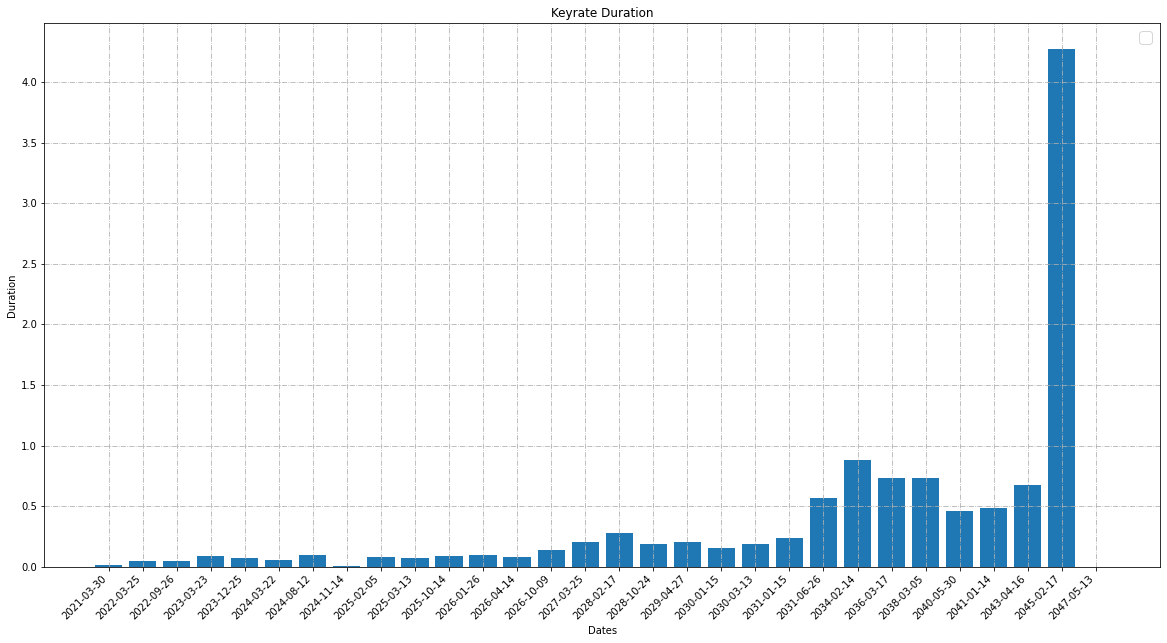

In [24]:
fig, ax = plt.subplots(figsize=(20, 10))

x=dates
y =keyrisk 

ax.bar(x,y)

leg = ax.legend(prop={'size': 16});
plt.grid(linestyle='dashdot')
plt.xticks(rotation=45, ha='right')
ax.set(xlabel='Dates', ylabel='Duration',
       title='Keyrate Duration')
plt.show()

In [35]:
pTable = pt.PrettyTable(['Dates','Duration'])
for i in range(0,len(dates)):
    pTable.add_row([dates[i],keyrisk[i] ])
pTable.align = 'c'
pTable.float_format = '.4'
pTable.add_row(["----------","--------"])
pTable.add_row(["Duration",sum(keyrisk)])
print(pTable)

+------------+----------+
|   Dates    | Duration |
+------------+----------+
| 2021-03-30 |  0.0123  |
| 2022-03-25 |  0.0448  |
| 2022-09-26 |  0.0504  |
| 2023-03-23 |  0.0867  |
| 2023-12-25 |  0.0757  |
| 2024-03-22 |  0.0568  |
| 2024-08-12 |  0.0950  |
| 2024-11-14 |  0.0078  |
| 2025-02-05 |  0.0773  |
| 2025-03-13 |  0.0689  |
| 2025-10-14 |  0.0921  |
| 2026-01-26 |  0.0977  |
| 2026-04-14 |  0.0785  |
| 2026-10-09 |  0.1349  |
| 2027-03-25 |  0.2036  |
| 2028-02-17 |  0.2794  |
| 2028-10-24 |  0.1874  |
| 2029-04-27 |  0.2067  |
| 2030-01-15 |  0.1503  |
| 2030-03-13 |  0.1908  |
| 2031-01-15 |  0.2401  |
| 2031-06-26 |  0.5637  |
| 2034-02-14 |  0.8832  |
| 2036-03-17 |  0.7335  |
| 2038-03-05 |  0.7346  |
| 2040-05-30 |  0.4623  |
| 2041-01-14 |  0.4836  |
| 2043-04-16 |  0.6780  |
| 2045-02-17 |  4.2721  |
| 2047-05-13 | -0.0000  |
| ---------- | -------- |
|  Duration  | 11.2483  |
+------------+----------+
